<a href="https://colab.research.google.com/github/jillianb2m/tcc-futebol-analise/blob/main/tcc_ml_futebol.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Imports

In [142]:
import pandas as pd
import traceback
import unicodedata
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from matplotlib.patches import FancyBboxPatch

# 2. Github

## 2.1. Clone

In [ ]:
%run "/content/drive/MyDrive/Colab Notebooks/tcc-clone-repo.py"

## 2.2. Commit

In [ ]:
%run "/content/drive/MyDrive/Colab Notebooks/tcc-commit-github.py"

📥 Clonando repositório...
✅ Notebook salvo
📁 Procurando tcc_ml_futebol.ipynb...

📁 Copiando tcc_ml_futebol.ipynb para o repositório...

📂 Arquivos atuais:

===== GIT STATUS =====
Digite a mensagem do commit: v2 ipynb

🚀 Enviando para GitHub...


# 3. Coleta e tratamento dos dados

In [ ]:
%run "/content/tcc-futebol-analise/src/scripts/preparar_base.py"


--- Resumo da Bases ---

Base 1
Shape: (17407, 79)

Base 2
Shape: (17282, 73)

Base 3
Shape: (17396, 79)
----------------------

Total de registros: 52,085
Total de colunas: 73
Linhas duplicadas: 4
Duplicatas removidas: 52,081 linhas restantes
  Outro: 16,376 (31.4%)
  Meia Central: 6,926 (13.3%)
  Volante: 6,357 (12.2%)
  Meia Direita: 5,017 (9.6%)
  Meia Esquerda: 4,964 (9.5%)
  Zagueiro: 3,676 (7.1%)
  Meia Atacante: 2,805 (5.4%)
  Goleiro: 2,324 (4.5%)
  Lateral Esquerdo: 930 (1.8%)
  Lateral Direito: 929 (1.8%)
  Ponta Direita: 894 (1.7%)
  Ponta Esquerda: 807 (1.5%)
  Centroavante: 76 (0.1%)

Removidos: 16,376 registros
Restantes: 35,705 registros
Redução: 31.4%


# 4. Clustering

## 4.1. Classe Clustering

In [163]:
class ClusterBrasileirao:
  def __init__(self, dataset_path):
    self.dataframe = pd.read_csv(dataset_path)

  def gerar_base(self, posicao_alvo=None, min_jogos=5):
    if posicao_alvo:
      df_filtro_alvo = self.dataframe[self.dataframe['Posicao_Real'] == posicao_alvo]
    else:
      df_filtro_alvo = self.dataframe.copy()

    regras_col_agregacao = {
        'rating': 'mean',
        'minutesPlayed': 'sum',
        'totalPass': 'mean',
        'accuratePass': 'mean',
        'totalShots': 'mean',
        'goals': 'sum',
        'totalTackle': 'mean',
        'interceptionWon': 'mean',
        'keyPass': 'mean',
        'goalAssist': 'sum',
        'Avg_X': 'mean',
        'Avg_Y': 'mean'
    }

    colunas_existentes = [col for col in regras_col_agregacao.keys() if col in df_filtro_alvo.columns]
    agregacoes_filtradas = {k: v for k, v in regras_col_agregacao.items() if k in colunas_existentes}

    df_agregado_alvo = df_filtro_alvo.groupby(['Jogador', 'Time', 'Posicao_Real']).agg(agregacoes_filtradas).reset_index()

    df_alvo = df_agregado_alvo[df_agregado_alvo['minutesPlayed'] >= min_jogos * 90].copy()

    variaveis_esperadas = [
      'rating', 'minutesPlayed',
      'totalPass', 'accuratePass',
      'totalShots', 'goals',
      'totalTackle', 'interceptionWon',
      'keyPass', 'goalAssist',
      'Avg_X', 'Avg_Y'
    ]

    v_metricas = [v for v in variaveis_esperadas if v in df_alvo.columns]

    self.dados_cluster = df_alvo[['Jogador', 'Time', 'Posicao_Real'] + v_metricas].copy()

    self.variaveis_metricas = v_metricas
    dados_metricos = self.dados_cluster[v_metricas].copy()

    return dados_metricos

  def explorar_variaveis_dataframe(self):
    print("********* Análise Exploratória *********")

    pd.set_option('display.max_columns', None)
    pd.set_option('display.expand_frame_repr', False)

    print(self.dados_cluster[self.variaveis_metricas].describe().round(2))
    print("\n")

    v_grande_escala = ['minutesPlayed']
    v_pequena_escala = ['rating', 'totalPass', 'accuratePass', 'totalShots',
                                'goals', 'totalTackle', 'interceptionWon', 'keyPass',
                                'goalAssist']
    v_posicao = ['Avg_X', 'Avg_Y']

    fig, axes = plt.subplots(3, 3, figsize=(24, 16))
    fig.suptitle('Distribuição das Variáveis de Desempenho', fontsize=18)

    if 'minutesPlayed' in self.variaveis_metricas:
        dados_melt_1 = pd.melt(self.dados_cluster[['minutesPlayed']])
        sns.boxplot(x='variable', y='value', hue='variable', data=dados_melt_1, ax=axes[0,0], palette='viridis', legend=False)
        axes[0,0].set_title('Minutos Jogados', fontsize=14)
        axes[0,0].set_ylabel('Minutos', fontsize=12)

    # Separar métricas por escala para melhor visualização (3 grupos)
    v_altissimo_volume = ['totalPass', 'accuratePass']  # Altíssimo volume (20-60)
    v_medio_volume = ['totalTackle', 'keyPass']  # Médio volume (0-8)
    v_baixo_volume = ['rating', 'goals', 'totalShots', 'goalAssist', 'interceptionWon']  # Baixo volume (0-10)

    # Gráfico 2: Altíssimo Volume
    v_disponiveis_altissimo = [v for v in v_altissimo_volume if v in self.variaveis_metricas]
    if v_disponiveis_altissimo:
        dados_melt_2 = pd.melt(self.dados_cluster[v_disponiveis_altissimo])
        sns.boxplot(x='variable', y='value', hue='variable', data=dados_melt_2, ax=axes[0,1], palette='viridis', legend=False)
        axes[0,1].set_title('Altíssimo Volume (Passes)', fontsize=14)
        axes[0,1].set_ylabel('Valores por Jogo (20-60)', fontsize=12)
        axes[0,1].tick_params(axis='x', rotation=45)

    # Gráfico 3: Médio Volume
    v_disponiveis_medio = [v for v in v_medio_volume if v in self.variaveis_metricas]
    if v_disponiveis_medio:
        dados_melt_3 = pd.melt(self.dados_cluster[v_disponiveis_medio])
        sns.boxplot(x='variable', y='value', hue='variable', data=dados_melt_3, ax=axes[0,2], palette='viridis', legend=False)
        axes[0,2].set_title('Médio Volume (Desarmes, Chaves)', fontsize=14)
        axes[0,2].set_ylabel('Valores por Jogo (0-8)', fontsize=12)
        axes[0,2].tick_params(axis='x', rotation=45)

    # Gráfico 4: Rating (escala específica)
    if 'rating' in self.variaveis_metricas:
        dados_melt_4 = pd.melt(self.dados_cluster[['rating']])
        sns.boxplot(x='variable', y='value', hue='variable', data=dados_melt_4, ax=axes[1,0], palette='viridis', legend=False)
        axes[1,0].set_title('Rating (Desempenho)', fontsize=14)
        axes[1,0].set_ylabel('Rating (6-8)', fontsize=12)

    # Gráfico 5: Assistências e Finalizações
    v_assist_shots = ['goalAssist', 'totalShots']
    v_disponiveis_assist = [v for v in v_assist_shots if v in self.variaveis_metricas]
    if v_disponiveis_assist:
        dados_melt_5 = pd.melt(self.dados_cluster[v_disponiveis_assist])
        sns.boxplot(x='variable', y='value', hue='variable', data=dados_melt_5, ax=axes[1,1], palette='viridis', legend=False)
        axes[1,1].set_title('Assistências e Finalizações', fontsize=14)
        axes[1,1].set_ylabel('Valores por Jogo (0-5)', fontsize=12)
        axes[1,1].tick_params(axis='x', rotation=45)

    # Gráfico 6: Gols (com outliers)
    if 'goals' in self.variaveis_metricas:
        dados_melt_6 = pd.melt(self.dados_cluster[['goals']])
        sns.boxplot(x='variable', y='value', hue='variable', data=dados_melt_6, ax=axes[1,2], palette='viridis', legend=False)
        axes[1,2].set_title('Gols (com Outliers)', fontsize=14)
        axes[1,2].set_ylabel('Gols por Jogo (0-20)', fontsize=12)

    # Gráfico 7: Interceptions
    if 'interceptionWon' in self.variaveis_metricas:
        dados_melt_7 = pd.melt(self.dados_cluster[['interceptionWon']])
        sns.boxplot(x='variable', y='value', hue='variable', data=dados_melt_7, ax=axes[2,0], palette='viridis', legend=False)
        axes[2,0].set_title('Interceptações', fontsize=14)
        axes[2,0].set_ylabel('Interceptações por Jogo (0-5)', fontsize=12)

    # Gráfico 8: Posicionamento (junto X e Y)
    v_disponiveis_posicao = [v for v in v_posicao if v in self.variaveis_metricas]
    if v_disponiveis_posicao:
        dados_melt_8 = pd.melt(self.dados_cluster[v_disponiveis_posicao])
        dados_melt_8['variable'] = dados_melt_8['variable'].replace({
            'Avg_X': 'Posição Horizontal',
            'Avg_Y': 'Posição Vertical'
        })
        sns.boxplot(x='variable', y='value', hue='variable', data=dados_melt_8, ax=axes[2,1], palette='viridis', legend=False)
        axes[2,1].set_title('Posicionamento em Campo', fontsize=14)
        axes[2,1].set_ylabel('Coordenadas (0-100)', fontsize=12)


        # Gráfico 9: Legenda do Posicionamento (centralizada)
    axes[2,2].axis('off')
    axes[2,2].set_title('Legenda - Posicionamento em Campo', fontsize=14)

    texto_legenda = (
        "Horizontal (Posição X):\n"
        "• 0 = Lado Esquerdo\n"
        "• 50 = Centro do Campo\n"
        "• 100 = Lado Direito\n\n"
        "Vertical (Posição Y):\n"
        "• 0 = Linha de Ataque\n"
        "• 50 = Linha do Meio Campo\n"
        "• 100 = Linha de Defesa\n\n"
        "Exemplos:\n"
        "• Goleiro: (50, 90)\n"
        "• Zagueiro: (50, 75)\n"
        "• Volante: (50, 60)\n"
        "• Meia: (50, 40)\n"
        "• Atacante: (50, 20)"
    )

    rect = FancyBboxPatch((0.1, 0.15), 0.8, 0.7,
                          transform=axes[2,2].transAxes,
                          facecolor='lightblue', alpha=0.9,
                          edgecolor='navy', linewidth=2.0,
                          boxstyle='round,pad=0.5')  # Padding menor
    axes[2,2].add_patch(rect)

    axes[2,2].text(0.15, 0.50, texto_legenda, transform=axes[2,2].transAxes,
                  fontsize=14, ha='left', va='center')

    plt.tight_layout()
    plt.savefig('boxplot_variaveis_melhorado.png', dpi=300, bbox_inches='tight')
    plt.show()


## 4.2. Main

********* Análise Exploratória *********
       rating  minutesPlayed  totalPass  accuratePass  totalShots   goals  totalTackle  interceptionWon  keyPass  goalAssist   Avg_X   Avg_Y
count  260.00         260.00     260.00        260.00      260.00  260.00       260.00           260.00   260.00      260.00  260.00  260.00
mean     6.94        1206.23      25.13         20.79        1.39    3.10         0.91             0.36     1.04        1.80   58.45   50.97
std      0.20         892.60      12.60         11.83        0.55    4.06         0.51             0.29     0.57        2.39    1.96    6.26
min      6.44         450.00       7.31          4.50        0.38    0.00         0.08             0.00     0.08        0.00   53.13   34.95
25%      6.80         614.75      15.22         11.39        1.00    1.00         0.52             0.14     0.58        0.00   57.20   46.63
50%      6.94         877.00      23.33         19.42        1.27    2.00         0.84             0.31     0.93 

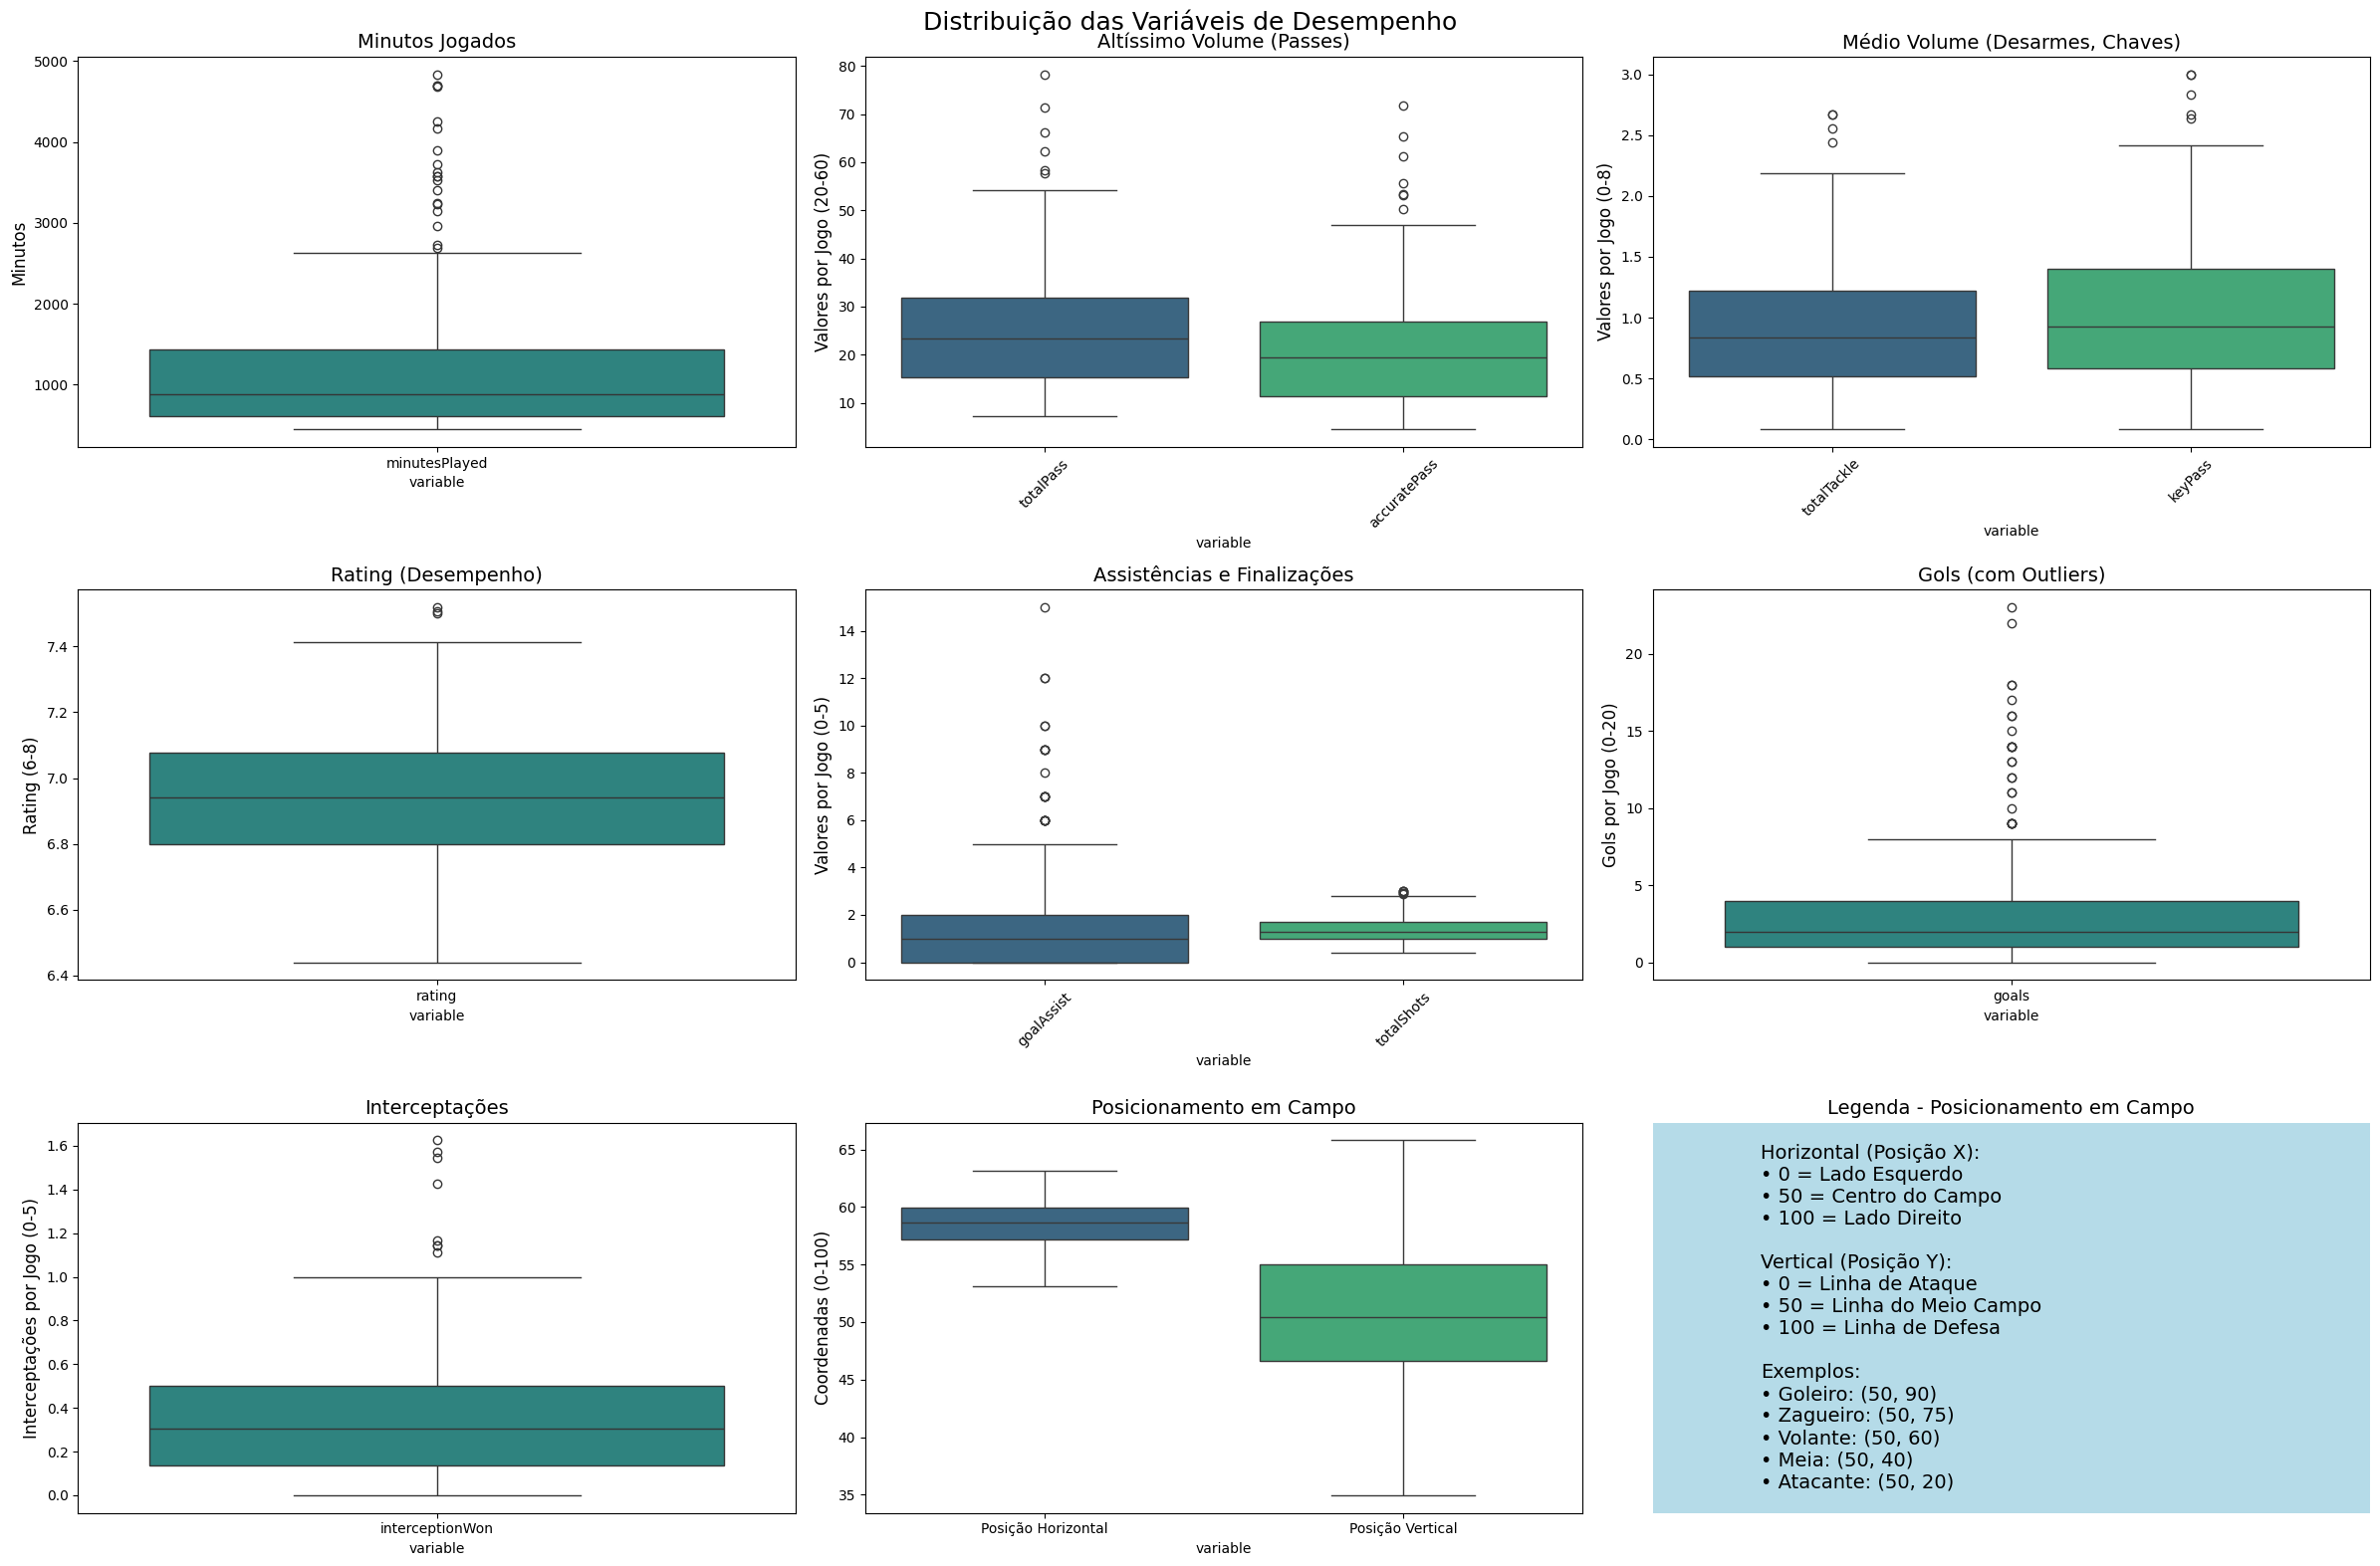

In [164]:
def main(pos_alvo="Meia Central", min_jogos=5):
  resultado_final = ClusterBrasileirao('datasets/processed/brasileirao_opta_final.csv')

  try:
    dados_metricos = resultado_final.gerar_base(pos_alvo, min_jogos)
  except Exception as e:
    print('Erro ao gerar dados métricos: ' + traceback.format_exc())

  resultado_final.explorar_variaveis_dataframe()

  return dados_metricos

if __name__ == "__main__":
    dados_metricos = main()

In [25]:
dados_metricos

,rating,minutesPlayed,totalPass,accuratePass,totalShots,goals,totalTackle,interceptionWon,keyPass,goalAssist,Avg_X,Avg_Y
0,6.945455,581.0,12.363636,7.727273,1.363636,5.0,0.818182,0.000000,0.272727,2.0,59.479573,48.225676
4,6.883333,604.0,25.916667,22.416667,0.583333,0.0,0.833333,0.166667,0.833333,0.0,58.810673,45.093613
6,7.031250,1254.0,24.937500,20.000000,2.562500,2.0,2.187500,0.250000,1.250000,0.0,60.099827,56.005444
7,6.814286,492.0,24.142857,19.571429,1.857143,2.0,1.285714,0.142857,0.571429,0.0,56.180223,48.181296
11,6.900000,1036.0,40.692308,37.076923,0.384615,0.0,1.538462,0.846154,0.769231,0.0,55.386132,52.333740
...,...,...,...,...,...,...,...,...,...,...,...,...
850,6.973333,3580.0,15.311111,11.466667,1.755556,15.0,0.511111,0.200000,0.577778,5.0,60.172565,45.857445
854,6.891667,818.0,26.416667,22.500000,1.166667,1.0,1.416667,0.666667,0.916667,3.0,54.202307,58.625400
855,7.122222,616.0,35.111111,31.000000,1.444444,1.0,1.444444,0.444444,0.888889,0.0,54.861092,59.752709
856,6.700000,488.0,15.500000,10.250000,1.000000,1.0,0.625000,0.000000,0.750000,1.0,59.214109,50.980050
